In [17]:
import random
import matplotlib.pyplot as plt

In [28]:
def random_dna(length):
    return ''.join(random.choice('ACGT') for _ in range(length))


def mutate_sequence(seq, num_mutations):
    seq = list(seq)
    positions = random.sample(range(len(seq)), num_mutations)
    for pos in positions:
        bases = ['A', 'C', 'G', 'T']
        bases.remove(seq[pos])
        seq[pos] = random.choice(bases)
    return ''.join(seq)


def introduce_errors(seq, error_rate):
    seq = list(seq)
    for i in range(len(seq)):
        if random.random() < error_rate:
            bases = ['A', 'C', 'G', 'T']
            bases.remove(seq[i])
            seq[i] = random.choice(bases)
    return ''.join(seq)

def create_repeats(base_seq, distance):
    copy1 = base_seq
    copy2 = mutate_sequence(base_seq, distance)
    return [copy1, copy2]

def simulate_reads(copies, read_length, reads_per_copy, error_rate):
    reads = []
    
    for copy_id, seq in enumerate(copies):
        for _ in range(reads_per_copy):
            start = random.randint(0, len(seq) - read_length)
            read = seq[start:start+read_length]
            read = introduce_errors(read, error_rate)
            
            reads.append({
                "seq": read,
                "true_copy": copy_id
            })
    
    return reads

def detect_collisions(reads, copies):
    collisions = 0
    total = len(reads)
    
    for read in reads:
        read_seq = read["seq"]
        true_id = read["true_copy"]
        
        for other_id, seq in enumerate(copies):
            if other_id == true_id:
                continue
            
            if read_seq in seq:
                collisions += 1
                break
    
    return collisions

### Genome length of 1 million base pairs

In [33]:
genome_length = 1000000
reads_per_copy = 200
error_rate = 0.01
distance_between_copies = 5  # keep this fixed

base_seq = random_dna(genome_length)
copies = create_repeats(base_seq, distance_between_copies)

read_lengths = [20, 30, 50, 75, 100, 150, 200]

results = []

for L in read_lengths:
    reads = simulate_reads(copies, L, reads_per_copy, error_rate)
    collisions = detect_collisions(reads, copies)
    
    print(f"Read length: {L}, Collisions: {collisions:.4f}")
    results.append(collisions)

Read length: 20, Collisions: 345.0000
Read length: 30, Collisions: 297.0000
Read length: 50, Collisions: 246.0000
Read length: 75, Collisions: 204.0000
Read length: 100, Collisions: 139.0000
Read length: 150, Collisions: 86.0000
Read length: 200, Collisions: 39.0000


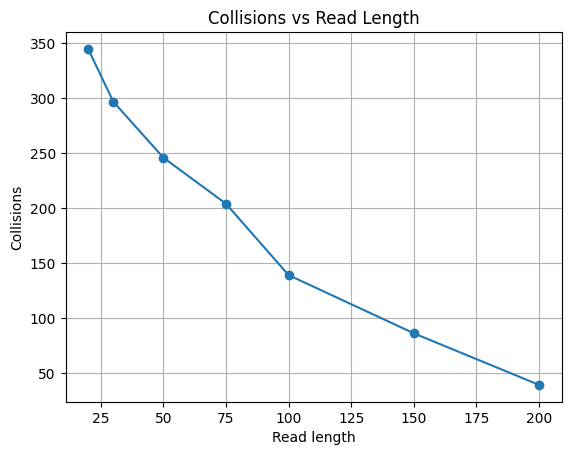

In [35]:
plt.figure()
plt.plot(read_lengths, results, marker='o')
plt.xlabel("Read length")
plt.ylabel("Collisions")
plt.title("Collisions vs Read Length")
plt.grid()
plt.show()

### Genome length of 10 million base pairs

In [ ]:
genome_length = 10000000
reads_per_copy = 200
error_rate = 0.01
distance_between_copies = 5  # keep this fixed

base_seq = random_dna(genome_length)
copies = create_repeats(base_seq, distance_between_copies)

read_lengths = [20, 30, 50, 75, 100, 150, 200]

results = []

for L in read_lengths:
    reads = simulate_reads(copies, L, reads_per_copy, error_rate)
    collisions = detect_collisions(reads, copies)
    
    print(f"Read length: {L}, Collisions: {collisions:.4f}")
    results.append(collisions)

plt.figure()
plt.plot(read_lengths, results, marker='o')
plt.xlabel("Read length")
plt.ylabel("Collisions")
plt.title("Collisions vs Read Length")
plt.grid()
plt.show()

Read length: 20, Collisions: 326.0000
Read length: 30, Collisions: 299.0000
Read length: 50, Collisions: 252.0000
Read length: 75, Collisions: 190.0000
